# Analysing openEO-Generated Interferograms for Earthquake-Induced Surface Deformation

This notebook demonstrates how to use openEO process [`sentinel1_sar_interferogram`](https://algorithm-catalogue.apex.esa.int/apps/sentinel1_sar_interferogram) to generate interferograms over a small area in the Amatrice–Norcia earthquake zone in central Italy. The results are then used to study surface deformation caused by earthquakes.

The computationally intensive interferogram generation is submitted to the Copernicus Data Space openEO backend. The resulting wrapped phase, unwrapped phase, and coherence bands are then downloaded and analysed locally with Python. This avoids the need to download large Sentinel-1 datasets and perform interferogram processing locally, which can be resource-intensive. The workflow aligns the interferograms, filters unreliable measurements, converts unwrapped phase to LOS displacement, and estimates a linear deformation trend over the 2016 earthquake sequence.

The study area and context are inspired by investigations of the 2016 Central Italy earthquake sequence:

* Chini et al. (2017): https://doi.org/10.1002/2017GL073580
* ESA Sentinel-1 Amatrice Earthquake Example: https://step.esa.int/main/gallery/gallery_sen1amatriceearthquake/

However, please note that the notebook is merely for demonstration purposes, has been tested on a relatively small region, and does not aim to reproduce the exact results of these studies. 

Let us start by importing the necessary libraries for the analysis.

In [1]:
# import required libraries
import glob
import re

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import openeo
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling

c:\Users\SHARMAP\AppData\Local\miniconda3\envs\cdse\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


### Connect to CDSE backend

As the first step, we connect to the Copernicus Data Space openEO backend and authenticate. This allows us to submit the interferogram generation job to the backend for processing.

In [2]:

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Fetch Sentinel-1 interferograms

Now that we are connected to the CDSE backend, let us call the [`sentinel1_sar_interferogram`](https://algorithm-catalogue.apex.esa.int/apps/sentinel1_sar_interferogram) User-Defined-Process (UDP).

This process generates a time series of Sentinel-1 interferometric coherence, wrapped interferograms, and unwrapped interferograms for user‑defined interferometric pairs.

In the following cell, we call the `sentinel1_sar_interferogram` process with VV polarisation, IW1 sub-swath observations over a spatial area in Italy between August and November 2016, and a temporal baseline of 6 days. 

A similar workflow has also been discussed in: https://doi.org/10.1002/2016GL071687.

In [3]:
s1_interferogram = connection.datacube_from_process(
    "sentinel1_sar_interferogram",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
    polarization="VV",
    sub_swath="IW1",
    spatial_extent={
        "west": 13.10,
        "south": 42.60,
        "east": 13.38,
        "north": 42.78
    },
    temporal_baseline=6,
    temporal_extent = ["2016-08-18", "2016-11-18"]
)

As a next step, let us submit the workflow as an openEO job to the CDSE backend. The backend generates interferograms using Sentinel-1 data available in the cloud. This is where the computationally expensive part of the workflow happens in the CDSE cloud environment. The resulting interferograms are then downloaded for further analysis.

In [4]:
job = s1_interferogram.create_job(title="SAR interferogram VV only")
job.start_and_wait()

0:00:00 Job 'j-260825064348430d9cb8b1bd59665994': send 'start'
0:00:02 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:07 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:14 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:22 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:32 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:44 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:59 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:01:19 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:01:43 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:02:13 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:02:50 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:03:37 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:04:35 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:05

<BatchJob job_id='j-260825064348430d9cb8b1bd59665994'>

In [ ]:
result = job.get_results()
result.download_files("sar_interferogram/") 

[WindowsPath('sar_interferogram/phase_coh_20160822T165740_20160828T165658.tif'),
 WindowsPath('sar_interferogram/phase_coh_20160828T165658_20160903T165740.tif'),
 WindowsPath('sar_interferogram/phase_coh_20160927T165741_20161003T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161003T165659_20161009T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161009T165741_20161015T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161015T165659_20161021T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161021T165741_20161027T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161027T165659_20161102T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161102T165741_20161108T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161108T165659_20161114T165741.tif'),
 WindowsPath('sar_interferogram/job-results.json')]

### Analyse interferograms locally

Interferometric Synthetic Aperture Radar (InSAR) is a powerful remote sensing technique that can measure ground displacement with centimetric to millimetric precision. Unlike SAR intensity images, interferograms retain phase information that is sensitive to changes in the distance between the satellite and the Earth's surface.

Traditionally, InSAR processing requires downloading large volumes of SAR data and performing computationally intensive processing steps locally. However, with the openEO platform, we can leverage cloud-based processing capabilities to generate interferograms directly in the cloud, significantly reducing the need for local resources.

At this point, we have successfully generated interferograms using the openEO backend and downloaded the results for further analysis. The next steps involve:
* loading the interferogram data and visualising it,
* aligning the interferograms to a common grid,
* converting the unwrapped phase to line-of-sight (LOS) displacement, and
* estimating a linear deformation trend over the 2016 earthquake sequence.

Let us start by defining the default settings for plots that will later be used to visualise the interferograms and displacement maps.

In [4]:
# this is the defaults that will be used later for plotssss
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
})

### Load interferogram products generated using the openEO process `sentinel1_sar_interferogram`

Each Interferogram is stored as a GeoTIFF file with three bands: 
* wrapped phase: representing the interferometric phase difference restricted to the interval between -π and π radians, 
* unwrapped phase: where phase ambiguities have been resolved to obtain a continuous phase field that can be related to surface displacement,
* coherence: which measures the similarity between the two SAR acquisitions and provides an indication of the reliability of the interferometric signal.

You can find more detailed information about the workflow and key steps involved in this link: https://github.com/cloudinsar/s1-workflows/tree/main

In [6]:
# let us load all the gtifs 
tif_paths = sorted(glob.glob("sar_interferogram/phase_coh_*.tif"))
pair_re = re.compile(r"phase_coh_(\d{8}T\d{6})_\d{8}T\d{6}\.tif$")

# these are pairs of interferograms so let us load them and sort them by date
pairs = []
crs = None
for path in tif_paths:
    with rasterio.open(path) as src:
        # description 
        desc = [d.lower() for d in src.descriptions]
        # indices of bands
        wrapped_idx = next(i for i, d in enumerate(desc) if "phase" in d and "unw" not in d)
        unwrapped_idx = next(i for i, d in enumerate(desc) if "unw" in d)
        coh_idx = next(i for i, d in enumerate(desc) if "coh" in d)
        
        # read the data and store it in a dictionary
        data = src.read()
        transform, shape = src.transform, src.shape
        crs = src.crs
        print(f"Loaded {path} of shape: {shape}")
    # append the data to the list of pairs
    pairs.append({
        "date": pd.Timestamp(pair_re.search(path).group(1)),
        "wrapped": data[wrapped_idx],
        "unwrapped": data[unwrapped_idx],
        "coherence": data[coh_idx],
        "transform": transform,
        "shape": shape,
    })
# sort the pairs by date
pairs.sort(key=lambda p: p["date"])
print(f"Loaded {len(pairs)} interferogram pairs from {len(tif_paths)} GeoTIFFs, CRS: {crs}")

Loaded sar_interferogram\phase_coh_20160822T165740_20160828T165658.tif of shape: (1914, 6520)
Loaded sar_interferogram\phase_coh_20160828T165658_20160903T165740.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20160927T165741_20161003T165659.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20161003T165659_20161009T165741.tif of shape: (1856, 6291)
Loaded sar_interferogram\phase_coh_20161009T165741_20161015T165659.tif of shape: (1914, 6520)
Loaded sar_interferogram\phase_coh_20161015T165659_20161021T165741.tif of shape: (1863, 6339)
Loaded sar_interferogram\phase_coh_20161021T165741_20161027T165659.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20161027T165659_20161102T165741.tif of shape: (1863, 6339)
Loaded sar_interferogram\phase_coh_20161102T165741_20161108T165659.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20161108T165659_20161114T165741.tif of shape: (1863, 6340)
Loaded 10 interferogram pairs from 10 GeoTIFFs, CRS: EPSG:43

Since each interferogram pair has a slightly different footprint (due to orbit geometry), to be able to do pixel-wise comparision, we reproject every pair onto a shared raster grid in the following cell. This will then allow the time dimension to be stacked and later compared pixel by pixel.

In [7]:
# get the resolution of the first pair and the bounding box of all pairs
res_x, res_y = abs(pairs[0]["transform"].a), abs(pairs[0]["transform"].e)
xmin = min(p["transform"].c for p in pairs)
ymax = max(p["transform"].f for p in pairs)
xmax = max(p["transform"].c + p["shape"][1] * p["transform"].a for p in pairs)
ymin = min(p["transform"].f + p["shape"][0] * p["transform"].e for p in pairs)

# compute the width and height of the aligned cube and the final transform
width = int(round((xmax - xmin) / res_x))
height = int(round((ymax - ymin) / res_y))
dst_transform = from_origin(xmin, ymax, res_x, res_y)

# align the bands to the same grid
def align(band, transform):
    dst = np.full((height, width), np.nan, dtype="float32")
    reproject(source=band, destination=dst, src_transform=transform, src_crs=crs,
              dst_transform=dst_transform, dst_crs=crs, src_nodata=np.nan, dst_nodata=np.nan,
              resampling=Resampling.nearest)  # nearest avoids blending across the phase wrap
    return dst

# let us create an xarray dataset with the aligned bands to have all in 1
ds = xr.Dataset(
    {
        "wrapped_phase": (("time", "y", "x"), np.stack([align(p["wrapped"], p["transform"]) for p in pairs])),
        "unwrapped_phase": (("time", "y", "x"), np.stack([align(p["unwrapped"], p["transform"]) for p in pairs])),
        "coherence": (("time", "y", "x"), np.stack([align(p["coherence"], p["transform"]) for p in pairs])),
    },
    coords={
        "time": pd.DatetimeIndex([p["date"] for p in pairs]),
        "y": ymax - res_y * (np.arange(height) + 0.5),
        "x": xmin + res_x * (np.arange(width) + 0.5),
    },
).sortby("time")

print(f"Aligned cube shape: {ds['coherence'].shape}")
print(f"Bands in the cube: {list(ds.data_vars)}")

Aligned cube shape: (10, 1924, 6622)
Bands in the cube: ['wrapped_phase', 'unwrapped_phase', 'coherence']


Before moving on to further analysis, let us quickly visualise the downloaded data:

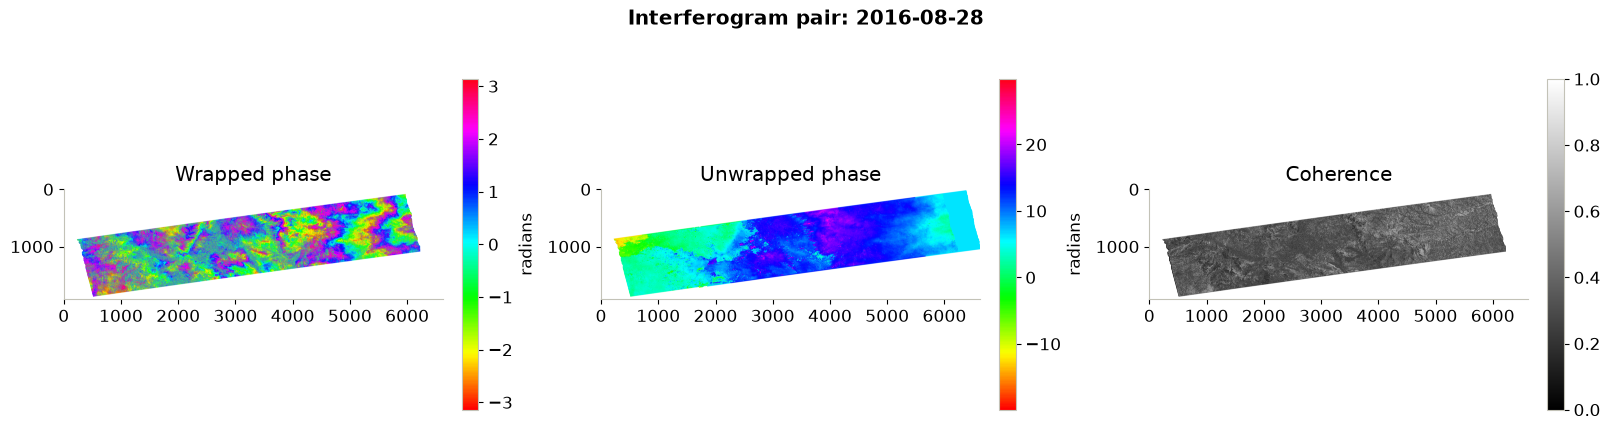

In [27]:
# Quicklook: second pair in the stack
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
im0 = axs[0].imshow(ds["wrapped_phase"].isel(time=1), cmap="hsv")
axs[0].set_title("Wrapped phase")
fig.colorbar(im0, ax=axs[0], label="radians", shrink=0.8)
im1 = axs[1].imshow(ds["unwrapped_phase"].isel(time=1), cmap="hsv")
axs[1].set_title("Unwrapped phase")
fig.colorbar(im1, ax=axs[1], label="radians", shrink=0.8)
im2 = axs[2].imshow(ds["coherence"].isel(time=1), cmap="gray", vmin=0, vmax=1)
axs[2].set_title("Coherence")
fig.colorbar(im2, ax=axs[2], shrink=0.8)
for ax in axs:
    ax.grid(False)
fig.suptitle(f"Interferogram pair: {pd.Timestamp(ds['wrapped_phase'].time.values[1]).date()}", fontweight="bold")
plt.show()

As seen in the quicklook, the wrapped phase shows a characteristic fringe pattern that indicates surface displacement, while the unwrapped phase provides a continuous representation of the displacement field. The coherence map highlights areas of high and low coherence, which can be used to assess the reliability of the measurements.

### Convert unwrapped phase to line-of-sight displacement

The unwrapped phase can be converted to line-of-sight (LOS) displacement using the following formula:
$$d = -(λ/4π) × Δφ$$

where,
- λ (wavelength) for Sentinel-1 VV = 0.0554 m (https://pmc.ncbi.nlm.nih.gov/articles/PMC7032057/)
- Negative values = motion away from the satellite
- Positive values = motion toward satellite


For the detailed guide to the process and the underlying theory, please refer to: https://hyp3-docs.asf.alaska.edu/guides/insar_product_guide/

In [9]:
LAMBDA_M = 0.05546          
COHERENCE_THRESHOLD = 0.50  
GRADIENT_PERCENTILE = 98    

displacement = -(LAMBDA_M / (4 * np.pi)) * ds["unwrapped_phase"]  

Once we have converted the unwrapped phase to LOS displacement, we can filter out unreliable measurements using coherence and local phase gradients.

Therefore, in the next step, we will flag pixels with a very steep local phase gradient in each pair. These steep gradients are usually indicative of residual fringe or unwrapping errors rather than real ground motion.

In [10]:
# res_y and res_x are the pixel sizes in y and x directions
res_y = float(abs(ds.y[1] - ds.y[0]))
res_x = float(abs(ds.x[1] - ds.x[0]))

# compute the gradient of the unwrapped phase to identify areas with steep phase changes
dy, dx = np.gradient(ds["unwrapped_phase"].values, res_y, res_x, axis=(1, 2))

# the gradient magnitude is calculated using the hypotenuse of the gradients in both directions.
gradient_mag = np.hypot(dx, dy)

# then determine a cutoff value based on the 98th percentile of the gradient magnitudes
gradient_cutoff = np.nanpercentile(gradient_mag, GRADIENT_PERCENTILE, axis=(1, 2), keepdims=True)
print(f"Gradient cutoff (98th percentile) per pair: {gradient_cutoff.flatten()}")

Gradient cutoff (98th percentile) per pair: [14794.885 14765.238 16752.332 17410.479 16683.742 15408.414 15845.177
 14510.612 15859.367 15214.134]


Let us further remove pixels with low coherence or extreme phase gradients to ensure that we are only considering reliable measurements for further analysis. 

In [12]:
# set conditions for unreliable pixels based on coherence and gradient magnitude
unreliable = (ds["coherence"].values < COHERENCE_THRESHOLD) | (gradient_mag >= gradient_cutoff)
displacement = displacement.where(~unreliable)
print(f"Displacement cube shape: {displacement.shape}, valid fraction per pair: {displacement.notnull().mean(dim=('y', 'x')).values}")

Displacement cube shape: (10, 1924, 6622), valid fraction per pair: [0.12597459 0.12238932 0.13288314 0.10770742 0.15729062 0.15217686
 0.16145914 0.13822091 0.12489906 0.13644738]


Let us check how many pixels remain or are retained as a valid fraction after filtering based on the above criteria. This will give us an idea of how much valid displacement is available for further analysis.

In [13]:
# remaining valid fraction of pixels after masking
valid_fraction = displacement.notnull().mean(dim=("y", "x"))
for t, frac in zip(pd.to_datetime(displacement.time.values), valid_fraction.values):
    print(f"{t.date()}: {frac:.1%} pixels retained after coherence/gradient masking")

2016-08-22: 12.6% pixels retained after coherence/gradient masking
2016-08-28: 12.2% pixels retained after coherence/gradient masking
2016-09-27: 13.3% pixels retained after coherence/gradient masking
2016-10-03: 10.8% pixels retained after coherence/gradient masking
2016-10-09: 15.7% pixels retained after coherence/gradient masking
2016-10-15: 15.2% pixels retained after coherence/gradient masking
2016-10-21: 16.1% pixels retained after coherence/gradient masking
2016-10-27: 13.8% pixels retained after coherence/gradient masking
2016-11-02: 12.5% pixels retained after coherence/gradient masking
2016-11-08: 13.6% pixels retained after coherence/gradient masking


###  Estimating a linear deformation trend

Each unwrapped interferogram represents the line-of-sight displacement difference between two acquisitions. The following regression is therefore included only as an illustrative pixel-wise analysis. It should not be interpreted as a cumulative deformation time series or as a definitive ground velocity estimate.

First let us convert the acquisition dates to a numeric time axis in days since the first acquisition. 

In [14]:
# prepare displacement stack and time array
displacement_stack = displacement.values  
dates = pd.to_datetime(displacement.time.values)
print(f"Dates of interferogram pairs: {[d.date() for d in dates]}")

# compute the time in days since the first interferogram pair
t_days = (dates - dates[0]).days.to_numpy(dtype="float64")
t = t_days[:, None, None]

Dates of interferogram pairs: [datetime.date(2016, 8, 22), datetime.date(2016, 8, 28), datetime.date(2016, 9, 27), datetime.date(2016, 10, 3), datetime.date(2016, 10, 9), datetime.date(2016, 10, 15), datetime.date(2016, 10, 21), datetime.date(2016, 10, 27), datetime.date(2016, 11, 2), datetime.date(2016, 11, 8)]


Next, we will build validity masks and identify pixels with at least two usable observations for a fitted deformation trend to ensure that we have enough data points for a reliable linear fit.

In [15]:
# valid pixels are those that are not NaN in the displacement stack
valid = ~np.isnan(displacement_stack)
y = np.where(valid, displacement_stack, 0.0)

# count the number of valid pixels for each pixel location across all time steps
n_valid = valid.sum(axis=0)
n_valid_f = n_valid.astype("float64")
enough_data = n_valid >= 2
print(f"Pixels with enough data for linear regression: {enough_data.mean():.1%} of the area")

Pixels with enough data for linear regression: 27.0% of the area


As mentioned earlier, we will perform weighted per-pixel fit of a linear deformation trend over time for each pixel using the valid displacement observations. The main formula followed here is:

$$d = v \cdot t + d_0$$

where,
- d = displacement at time t
- v = velocity (rate of deformation)
- d_0 = initial displacement at the first acquisition

In [16]:
# compute the sums needed for linear regression
sum_t = np.where(valid, t, 0.0).sum(axis=0)
sum_tt = np.where(valid, t ** 2, 0.0).sum(axis=0)
sum_y = y.sum(axis=0)
sum_ty = (t * y).sum(axis=0)

# prepare the matrices for linear regression
A = np.stack([
    np.stack([sum_tt, sum_t], axis=-1),
    np.stack([sum_t, n_valid_f], axis=-1),
], axis=-2)  
b = np.stack([sum_ty, sum_y], axis=-1)

# compute the determinant of the matrix A to check for singularity
det = sum_tt * n_valid_f - sum_t ** 2
print(f"Determinant min: {np.nanmin(det)}, max: {np.nanmax(det)}")

# compute the solvable pixels based on enough data and non-zero determinant
solvable = enough_data & (det != 0)  
print(f"Valid pixels: {np.sum(solvable)} out of {solvable.size} ({100 * np.sum(solvable) / solvable.size:.1f}%)")


Determinant min: 0.0, max: 61681.0
Valid pixels: 3436696 out of 12740728 (27.0%)


Then derive the total displacement range over the observation period and the Peak line-of-sight (LOS) velocity.

In [23]:
# compute the velocity and intercept for each pixel using linear regression
velocity = np.full(n_valid.shape, np.nan)
intercept = np.full(n_valid.shape, np.nan)

coeffs = np.linalg.solve(A[solvable], b[solvable][..., None])[..., 0] 
velocity[solvable] = coeffs[:, 0] 
intercept[solvable] = coeffs[:, 1]

# normal equations for y = velocity*t + intercept:
total_displacement = velocity * t_days[-1] + intercept  # NaN propagates automatically where unsolved

print(f"Total displacement range: {np.nanmin(total_displacement):.3f} to {np.nanmax(total_displacement):.3f} m")
print(f"Peak LOS velocity: {np.nanmax(np.abs(velocity)) * 365.25 * 1000:.0f} mm/yr")

Total displacement range: -2.754 to 1.936 m
Peak LOS velocity: 18420 mm/yr


The total displacement calculated inline with the observation made by the authors of paper: https://doi.org/10.1002/2017GL073580, which reported that despite severe damage in the town of Amatrice, static surface displacement there was less than 4 cm. 

Let us now visualise the estimated cumulative LOS displacement and the underlying LOS velocity over the whole period, from the linear-trend fit above.

Map extent: 12.7236 to 13.9131°E, 42.3933 to 42.7388°N
Velocity range: -13479.6 to 18407.2 mm/yr


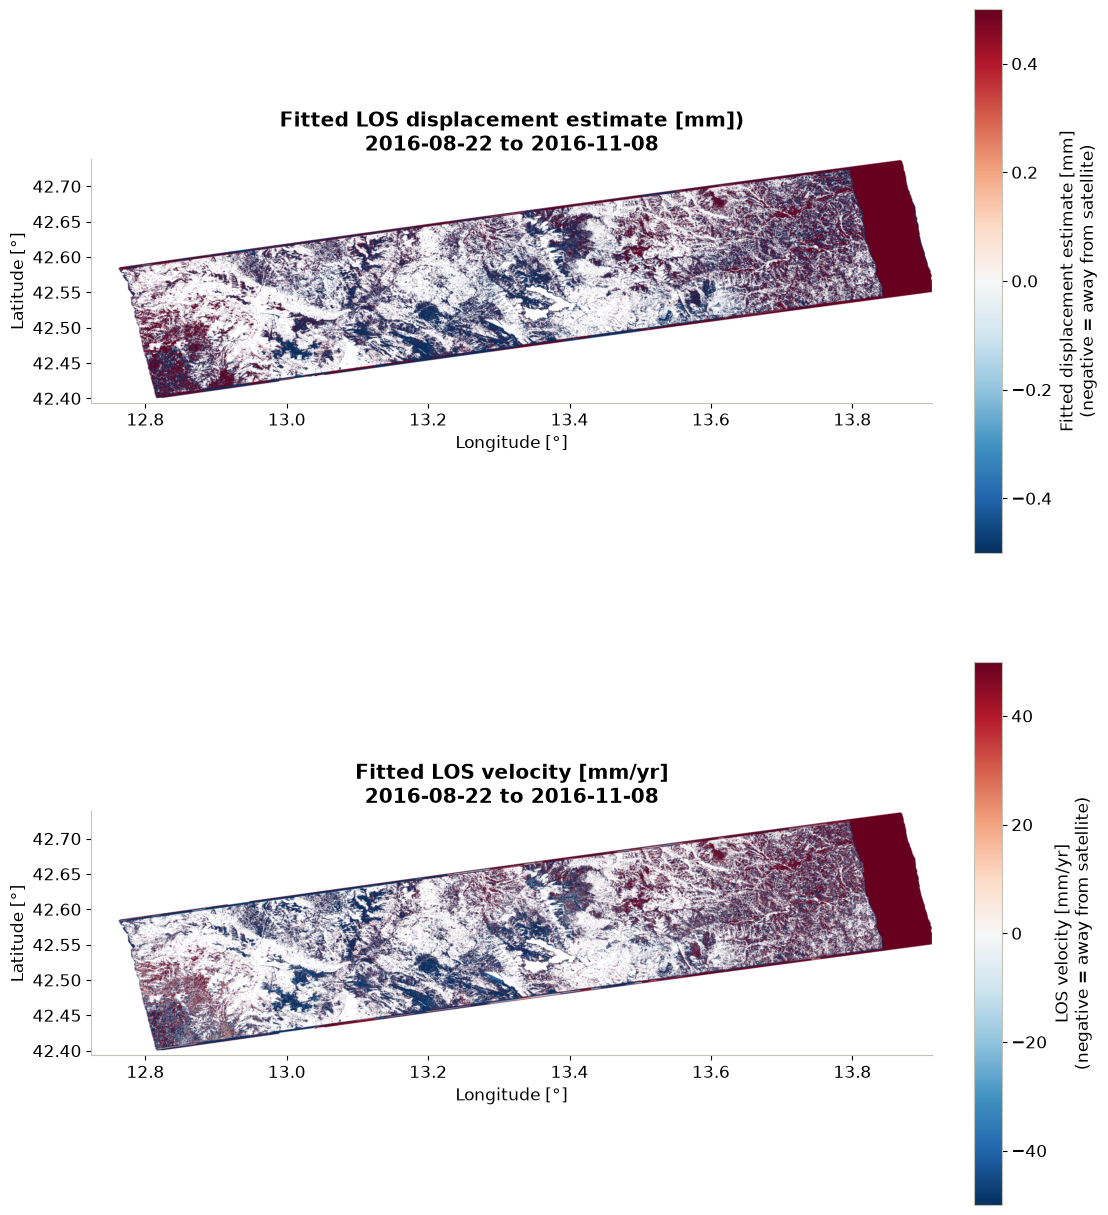

In [26]:
# Prepare extent (AOI was requested in EPSG:4326, so the axes are lon/lat)
extent = [float(displacement.x.min()), float(displacement.x.max()),
          float(displacement.y.min()), float(displacement.y.max())]
print(f"Map extent: {extent[0]:.4f} to {extent[1]:.4f}°E, {extent[2]:.4f} to {extent[3]:.4f}°N")

# convert velocity from m/day to mm/yr for easier interpretation
velocity_mm_yr = velocity*1000*365  
print(f"Velocity range: {np.nanmin(velocity_mm_yr):.1f} to {np.nanmax(velocity_mm_yr):.1f} mm/yr")

# plot the total displacement and velocity maps
fig, axs = plt.subplots(2, 1, figsize=(11, 13), constrained_layout=True)
for ax in axs:
    ax.grid(False)
    ax.set_xlabel("Longitude [°]")
    ax.set_ylabel("Latitude [°]")

im0 = axs[0].imshow(total_displacement*1000, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                     extent=extent, origin="upper", interpolation="bilinear")
axs[0].set_title("Fitted LOS displacement estimate [mm])\n" +
                  f"{dates[0].date()} to {dates[-1].date()}", fontweight="bold")
fig.colorbar(im0, ax=axs[0], shrink=0.85, label="Fitted displacement estimate [mm]\n(negative = away from satellite)")
im1 = axs[1].imshow(velocity_mm_yr, cmap="RdBu_r", vmin=-50.0, vmax=50.0,
                     extent=extent, origin="upper", interpolation="bilinear")
axs[1].set_title("Fitted LOS velocity [mm/yr]\n" +
                  f"{dates[0].date()} to {dates[-1].date()}", fontweight="bold")
fig.colorbar(im1, ax=axs[1], shrink=0.85, label="LOS velocity [mm/yr]\n(negative = away from satellite)")

plt.show()



In the plot above, we can see the net line-of-sight displacement and the underlying LOS velocity over the entire period, as inferred from the linear-trend fit above. The red areas indicate motion toward the satellite, while the blue areas indicate motion away from the satellite. The white or blank areas represent pixels with fewer valid pairs, which have been masked by coherence or phase-gradient filtering.

Furthermore, let us briefly examine the pixel with the largest fitted displacement and show its raw per-pair measurements against the fitted linear trend. This will help us understand how the linear fit was derived from noisy, partly-masked data, rather than being a literal running total of displacements.

In [ ]:
# find the extreme fitted pixel
peak_y, peak_x = np.unravel_index(np.nanargmax(np.abs(total_displacement)), total_displacement.shape)
print(f"Peak deformation pixel: row {peak_y}, col {peak_x}")
print(f"Fitted displacement over the period: {total_displacement[peak_y, peak_x]:.3f} m")

# Compute the fitted velocity and intercept for that pixel
pixel_displacement = displacement_stack[:, peak_y, peak_x]
pixel_velocity = velocity[peak_y, peak_x]
pixel_intercept = intercept[peak_y, peak_x]
print(f"Fitted velocity: {pixel_velocity * 365.25 * 1000:.0f} mm/yr "
      f"({'toward satellite' if pixel_velocity > 0 else 'away from satellite'})")


Peak deformation pixel: row 905, col 2620
Fitted displacement over the period: -2.754 m
Fitted velocity: -13489 mm/yr (away from satellite)


The selected pixel is the location with the largest absolute fitted displacement estimate. 

This information can be useful for understanding the spatial distribution of deformation in the study area and identifying areas of significant ground movement.

To have a better understanding of the deformation trend for that specific pixel, we can also visualise the selected pixel's valid per-pair displacement measurements along with its fitted linear trend. 

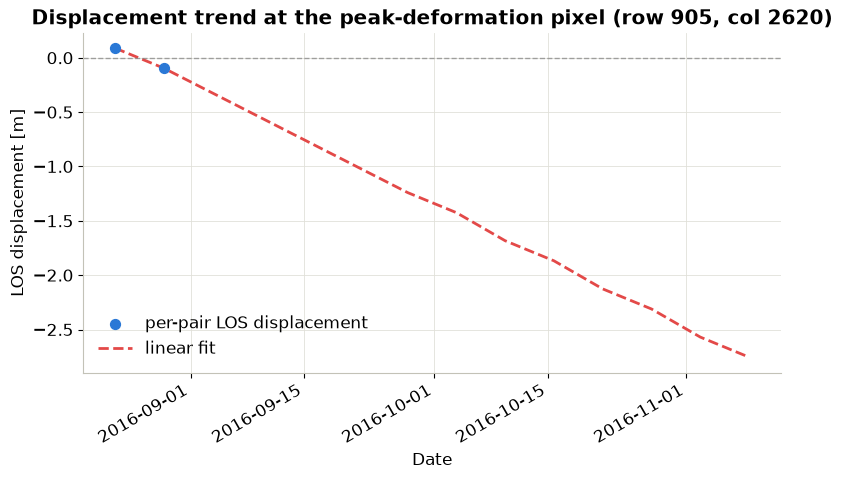

In [20]:
# Plot the raw per-pair measurements against the fitted trend
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(dates, pixel_displacement, s=50, color="#2a78d6", zorder=3, label="per-pair LOS displacement")
fit_line = pixel_velocity * t_days + pixel_intercept
ax.plot(dates, fit_line, color="#e34948", linestyle="--", linewidth=2, label="linear fit")
ax.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.7)

ax.set_ylabel("LOS displacement [m]")
ax.set_xlabel("Date")
ax.set_title(f"Displacement trend at the peak-deformation pixel (row {peak_y}, col {peak_x})", fontweight="bold")
ax.legend(frameon=False)

fig.autofmt_xdate()  # rotate date labels
plt.show()

This notebook was a brief demonstration of how an advanced openEO process can be used to generate interferograms and analyse earthquake-induced surface deformation using Sentinel-1 SAR data. 

The main idea wasn't to reproduce the exact results of the studies mentioned earlier, but rather to show how complex InSAR processing can be performed in the cloud using openEO, without the need to download large volumes of SAR data and perform computationally intensive processing steps locally. With openEO, users can leverage the CDSE's cloud-based processing capabilities via the openEO API and invest resources in detailed analysis of the results, without the overhead of downloading and processing Sentinel-1 data.